In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import matplotlib.ticker as mtick
# ── Chargement ──────────────────────────────────────────────────────────────
df = pd.read_csv("toutes_experiences..csv")
datasets = df['dataset'].unique()
methods  = df['imputation_method'].unique()

palette = {'KNN': '#2196F3', 'MICE': '#4CAF50', 'Moyenne/Mode': '#FF9800'}

# Test

# 1. Effet de l'imputation initiale

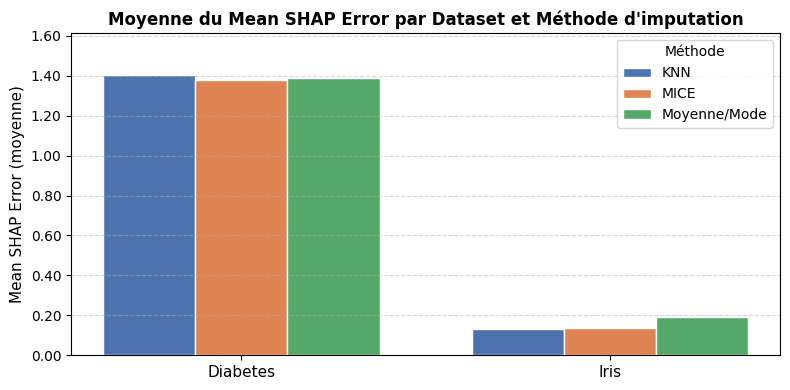

In [ ]:

# Moyenne du mean_shap_error par dataset et méthode
df_avg = df.groupby(["dataset", "imputation_method"])["mean_shap_error"].mean().reset_index()

datasets = df_avg["dataset"].unique()
methods = df_avg["imputation_method"].unique()

x = np.arange(len(datasets))
width = 0.25
colors = {"KNN": "#4C72B0", "MICE": "#DD8452", "Moyenne/Mode": "#55A868"}

fig, ax = plt.subplots(figsize=(8, 4))

for i, method in enumerate(methods):
    subset = df_avg[df_avg["imputation_method"] == method]
    values = [subset[subset["dataset"] == d]["mean_shap_error"].values[0] for d in datasets]
    ax.bar(x + i * width, values, width=width, label=method, color=colors[method], edgecolor="white")

ax.set_xticks(x + width)
ax.set_xticklabels([d.capitalize() for d in datasets], fontsize=11)
ax.set_ylabel("Mean SHAP Error (moyenne)", fontsize=11)
ax.set_title("Moyenne du Mean SHAP Error par Dataset et Méthode d'imputation", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}"))
ymax = df_avg["mean_shap_error"].max()
ax.set_ylim(0, ymax * 1.15)
ax.legend(title="Méthode", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("bar_shap_error.png", dpi=150)
plt.show()

# Effet du taux des données manquantes

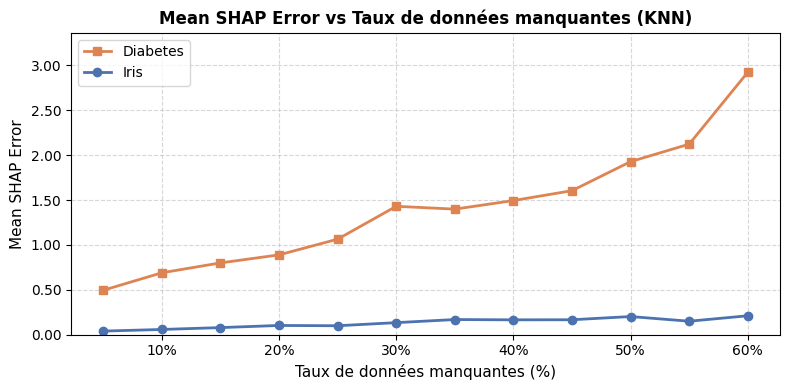

In [ ]:

# Chargement des données
df = pd.read_csv("toutes_experiences_iris.csv")

# Filtrage : KNN uniquement, datasets iris et diabetes
df_knn = df[(df["imputation_method"] == "KNN") & (df["dataset"].isin(["iris", "diabetes"]))]

colors = {"iris": "#4C72B0", "diabetes": "#DD8452"}
markers = {"iris": "o", "diabetes": "s"}

fig, ax = plt.subplots(figsize=(8, 4))

for dataset, group in df_knn.groupby("dataset"):
    group = group.sort_values("missing_rate")
    ax.plot(
        group["missing_rate"] * 100,
        group["mean_shap_error"],
        label=dataset.capitalize(),
        color=colors[dataset],
        marker=markers[dataset],
        linewidth=2,
        markersize=6,
    )

ax.set_xlabel("Taux de données manquantes (%)", fontsize=11)
ax.set_ylabel("Mean SHAP Error", fontsize=11)
ax.set_title("Mean SHAP Error vs Taux de données manquantes (KNN)", fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%g%%'))
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

# Limiter l'axe Y aux vraies valeurs des deux courbes
ymax = df_knn["mean_shap_error"].max()
ax.set_ylim(0, ymax * 1.15)  # juste 15% de marge au dessus du max réel

ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("shap_error_knn.png", dpi=150)
plt.show()

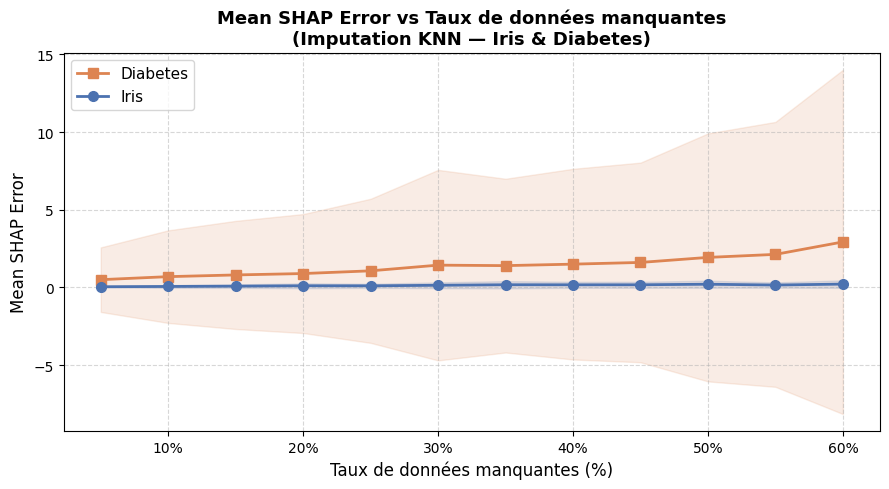

In [ ]:

# Chargement des données
df = pd.read_csv("toutes_experiences_iris.csv")

# Filtrage : KNN uniquement, datasets iris et diabetes
df_knn = df[(df["imputation_method"] == "KNN") & (df["dataset"].isin(["iris", "diabetes"]))]

# Couleurs et styles
colors = {"iris": "#4C72B0", "diabetes": "#DD8452"}
markers = {"iris": "o", "diabetes": "s"}

fig, ax = plt.subplots(figsize=(9, 5))

for dataset, group in df_knn.groupby("dataset"):
    group = group.sort_values("missing_rate")
    ax.plot(
        group["missing_rate"] * 100,
        group["mean_shap_error"],
        label=dataset.capitalize(),
        color=colors[dataset],
        marker=markers[dataset],
        linewidth=2,
        markersize=7,
    )
    # Bande d'incertitude ± std
    ax.fill_between(
        group["missing_rate"] * 100,
        group["mean_shap_error"] - group["std_shap_error"],
        group["mean_shap_error"] + group["std_shap_error"],
        color=colors[dataset],
        alpha=0.15,
    )

ax.set_xlabel("Taux de données manquantes (%)", fontsize=12)
ax.set_ylabel("Mean SHAP Error", fontsize=12)
ax.set_title("Mean SHAP Error vs Taux de données manquantes\n(Imputation KNN — Iris & Diabetes)", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%g%%'))
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("shap_error_knn.png", dpi=150)
plt.show()

# Distribution des scores de fiabilité par rapport au taux de données manquantes et à l'imputation intiale choisie

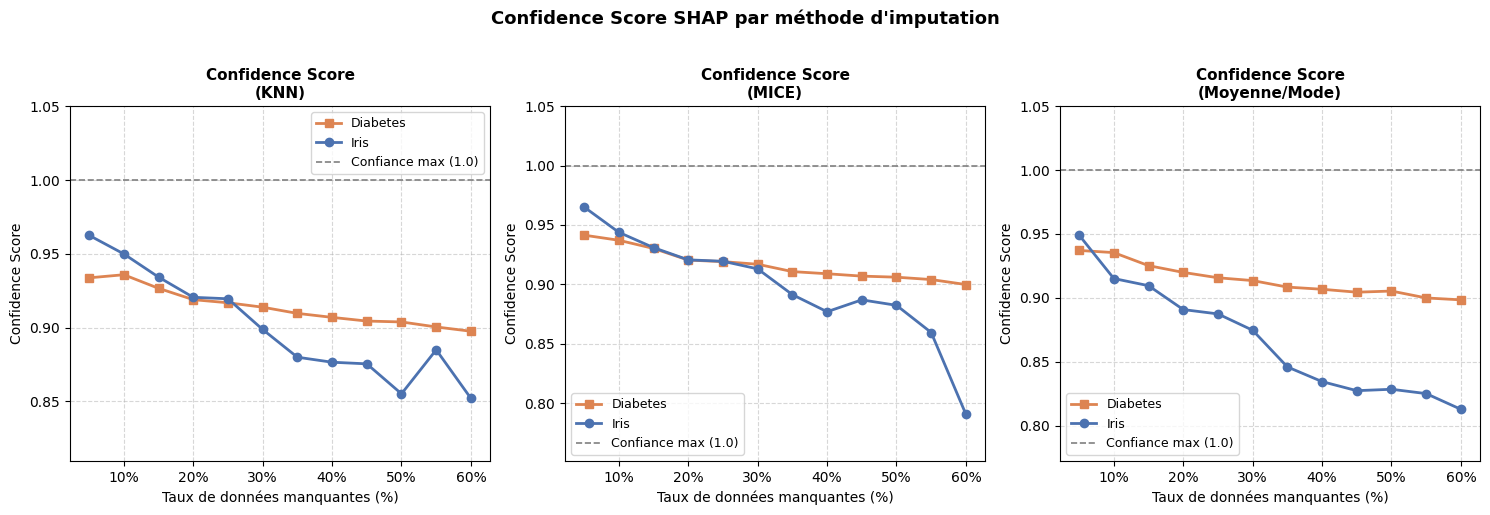

In [ ]:


colors  = {"iris": "#4C72B0", "diabetes": "#DD8452"}
markers = {"iris": "o", "diabetes": "s"}
methods = ["KNN", "MICE", "Moyenne/Mode"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, method in zip(axes, methods):
    df_m = df[(df["imputation_method"] == method) & (df["dataset"].isin(["iris", "diabetes"]))]

    for dataset, group in df_m.groupby("dataset"):
        group = group.sort_values("missing_rate")
        ax.plot(
            group["missing_rate"] * 100,
            group["mean_confidence"],
            label=dataset.capitalize(),
            color=colors[dataset],
            marker=markers[dataset],
            linewidth=2,
            markersize=6,
        )

    ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=1.2, label="Confiance max (1.0)")
    ax.set_xlabel("Taux de données manquantes (%)", fontsize=10)
    ax.set_ylabel("Confidence Score", fontsize=10)
    ax.set_title(f"Confidence Score\n({method})", fontsize=11, fontweight="bold")
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%g%%'))
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
    ymin = df_m["mean_confidence"].min()
    ax.set_ylim(max(0, ymin * 0.95), 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.5)

fig.suptitle("Confidence Score SHAP par méthode d'imputation",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("confidence_par_methode.png", dpi=150, bbox_inches="tight")
plt.show()

# Validation Statistuqe

# 1. Test de spearman

spearman = corrélation (score de fiabilité, MAE Missforest)

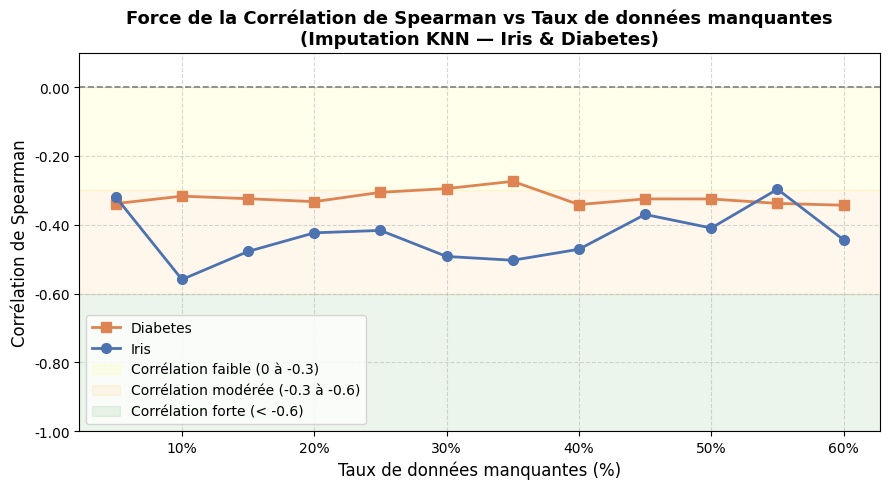

In [ ]:

markers = {"iris": "o", "diabetes": "s"}

fig, ax = plt.subplots(figsize=(9, 5))

for dataset, group in df_knn.groupby("dataset"):
    group = group.sort_values("missing_rate")
    ax.plot(
        group["missing_rate"] * 100,
        group["spearman_corr"],
        label=dataset.capitalize(),
        color=colors[dataset],
        marker=markers[dataset],
        linewidth=2,
        markersize=7,
    )

# Zones d'interprétation de la force
ax.axhspan(-0.3, 0,    color="yellow", alpha=0.08, label="Corrélation faible (0 à -0.3)")
ax.axhspan(-0.6, -0.3, color="orange", alpha=0.08, label="Corrélation modérée (-0.3 à -0.6)")
ax.axhspan(-1.0, -0.6, color="green",  alpha=0.08, label="Corrélation forte (< -0.6)")

# Ligne zéro
ax.axhline(y=0, color="gray", linestyle="--", linewidth=1.2)

ax.set_xlabel("Taux de données manquantes (%)", fontsize=12)
ax.set_ylabel("Corrélation de Spearman", fontsize=12)
ax.set_title("Force de la Corrélation de Spearman vs Taux de données manquantes\n(Imputation KNN — Iris & Diabetes)", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%g%%'))
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
ax.set_ylim(-1.0, 0.1)
ax.legend(fontsize=10, loc="lower left")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("spearman_corr_knn.png", dpi=150)
plt.show()

# 2. P-value


**Hypothèses :**

- $H_0$: il n'existe pas de corrélation  
- $H_1$: il existe une corrélation


Le test de spearman permet de calculer la p-value

$p < 0.05 \implies$ rejeter $H_0$

$p \geq 0.05 \implies$ ne pas rejeter $H_0$

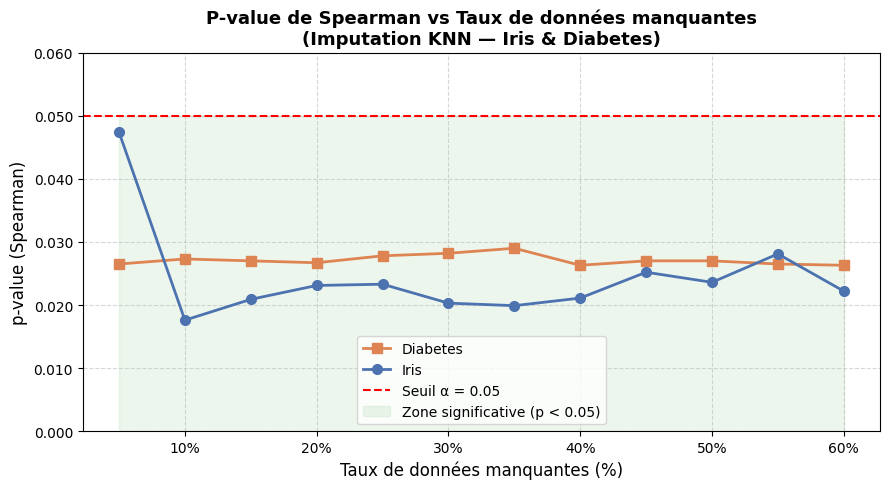

In [ ]:

colors  = {"iris": "#4C72B0", "diabetes": "#DD8452"}
markers = {"iris": "o", "diabetes": "s"}

fig, ax = plt.subplots(figsize=(9, 5))

for dataset, group in df_knn.groupby("dataset"):
    group = group.sort_values("missing_rate")

    pval_plot = []


    ax.plot(
        group["missing_rate"] * 100,
        pval_plot,
        label=dataset.capitalize(),
        color=colors[dataset],
        marker=markers[dataset],
        linewidth=2,
        markersize=7,
    )

ax.axhline(y=0.05, color="red", linestyle="--", linewidth=1.5, label="Seuil α = 0.05")
ax.fill_between([5, 60], 0, 0.05, color="green", alpha=0.07, label="Zone significative (p < 0.05)")

ax.set_xlabel("Taux de données manquantes (%)", fontsize=12)
ax.set_ylabel("p-value (Spearman)", fontsize=12)
ax.set_title("P-value de Spearman vs Taux de données manquantes\n(Imputation KNN — Iris & Diabetes)", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%g%%'))
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.3f'))
ax.set_ylim(0, 0.06)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("pval_knn.png", dpi=150)
plt.show()